In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../datasets/personal_finance_dataset_8000_extended.csv")

In [3]:
df.head()

,Date,Description,Amount,Category,PaymentMethod,Month
0,05-04-2025,IRCTC,20666.49,Travel,Debit Card,April
1,06-12-2025,Myntra,1919.05,Online Shopping,Net Banking,December
2,20-06-2025,BigBazaar,2837.68,Grocery,Debit Card,June
3,23-04-2025,Property Tax Online,1071.04,Bills,Net Banking,April
4,06-03-2025,Asus Store,10722.80,Electronics,Debit Card,March


In [4]:
df.shape

(8000, 6)

In [5]:
df.columns

Index(['Date', 'Description', 'Amount', 'Category', 'PaymentMethod', 'Month'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           8000 non-null   str    
 1   Description    8000 non-null   str    
 2   Amount         8000 non-null   float64
 3   Category       8000 non-null   str    
 4   PaymentMethod  8000 non-null   str    
 5   Month          8000 non-null   str    
dtypes: float64(1), str(5)
memory usage: 375.1 KB


In [7]:
df.isnull().sum()

Date             0
Description      0
Amount           0
Category         0
PaymentMethod    0
Month            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Date                 str
Description          str
Amount           float64
Category             str
PaymentMethod        str
Month                str
dtype: object

In [10]:
df.describe()

,Amount
count,8000.000000
mean,12551.954504
std,26196.803575
min,54.110000
25%,938.920000
50%,3328.625000
75%,11173.300000
max,149925.200000


In [11]:
df["Category"].value_counts()

Category
Online Shopping    831
Entertainment      824
Food               822
Healthcare         804
Electronics        797
Travel             789
Bills              788
Grocery            786
Transport          786
Clothing           773
Name: count, dtype: int64

In [12]:
df["PaymentMethod"].value_counts()

PaymentMethod
Net Banking    2023
Credit Card    2023
Debit Card     1993
UPI            1961
Name: count, dtype: int64

In [13]:
print(df["Category"].unique())
print("\nNumber of Categories:", df["Category"].nunique())

<StringArray>
[         'Travel', 'Online Shopping',         'Grocery',           'Bills',
     'Electronics',        'Clothing',   'Entertainment',            'Food',
       'Transport',      'Healthcare']
Length: 10, dtype: str

Number of Categories: 10


In [14]:
df["Description"] = df["Description"].str.lower()

In [15]:
df["Description"] = df["Description"].str.strip()

In [16]:
df.head()

,Date,Description,Amount,Category,PaymentMethod,Month
0,05-04-2025,irctc,20666.49,Travel,Debit Card,April
1,06-12-2025,myntra,1919.05,Online Shopping,Net Banking,December
2,20-06-2025,bigbazaar,2837.68,Grocery,Debit Card,June
3,23-04-2025,property tax online,1071.04,Bills,Net Banking,April
4,06-03-2025,asus store,10722.80,Electronics,Debit Card,March


In [17]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           8000 non-null   datetime64[us]
 1   Description    8000 non-null   str           
 2   Amount         8000 non-null   float64       
 3   Category       8000 non-null   str           
 4   PaymentMethod  8000 non-null   str           
 5   Month          8000 non-null   str           
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 375.1 KB


In [19]:
df["Year"] = df["Date"].dt.year
df["Month_Number"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [20]:
df.head()

,Date,Description,Amount,Category,PaymentMethod,Month,Year,Month_Number,Day,Weekday
0,2025-04-05,irctc,20666.49,Travel,Debit Card,April,2025,4,5,Saturday
1,2025-12-06,myntra,1919.05,Online Shopping,Net Banking,December,2025,12,6,Saturday
2,2025-06-20,bigbazaar,2837.68,Grocery,Debit Card,June,2025,6,20,Friday
3,2025-04-23,property tax online,1071.04,Bills,Net Banking,April,2025,4,23,Wednesday
4,2025-03-06,asus store,10722.80,Electronics,Debit Card,March,2025,3,6,Thursday


In [21]:
df.to_csv("../datasets/cleaned_dataset.csv", index=False)

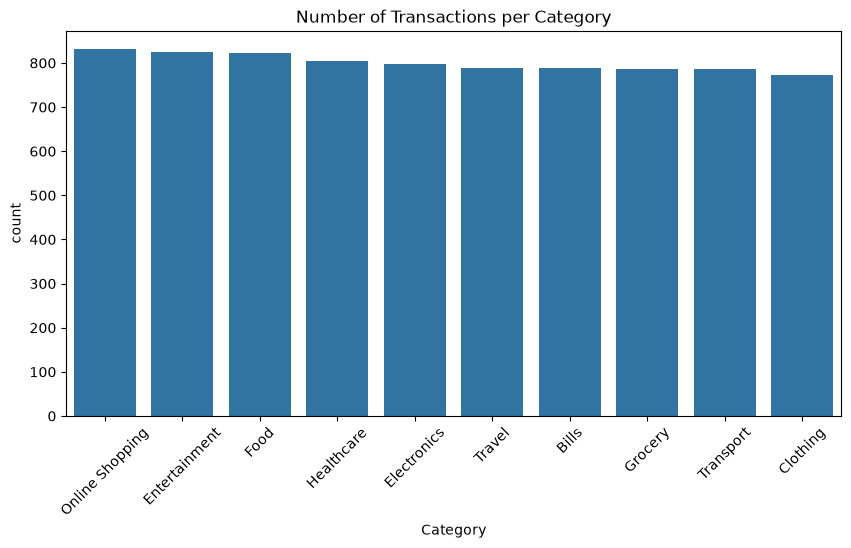

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Number of Transactions per Category")
plt.xticks(rotation=45)
plt.show()

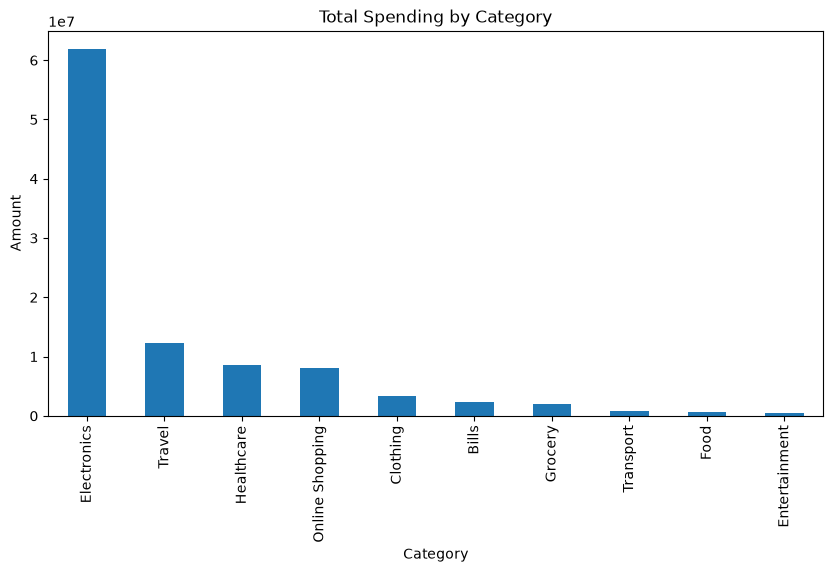

In [23]:
category_spending = (
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

category_spending.plot(kind="bar")

plt.title("Total Spending by Category")

plt.ylabel("Amount")

plt.show()

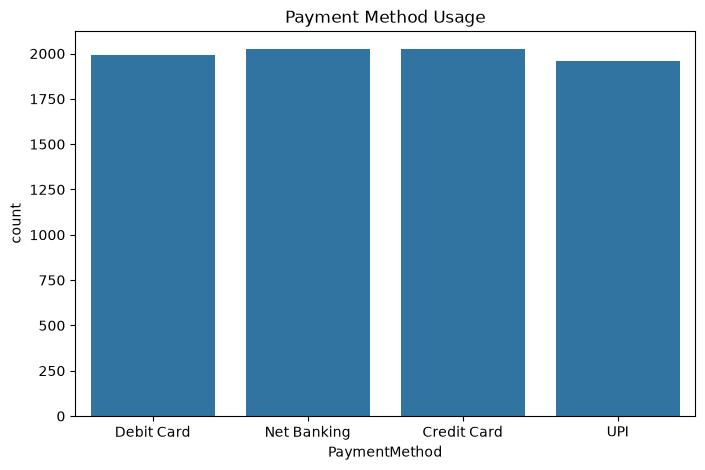

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="PaymentMethod"
)

plt.title("Payment Method Usage")

plt.show()

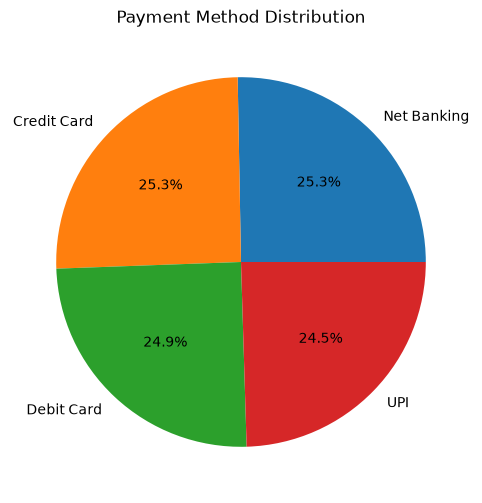

In [25]:
payment_counts = df["PaymentMethod"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")

plt.show()

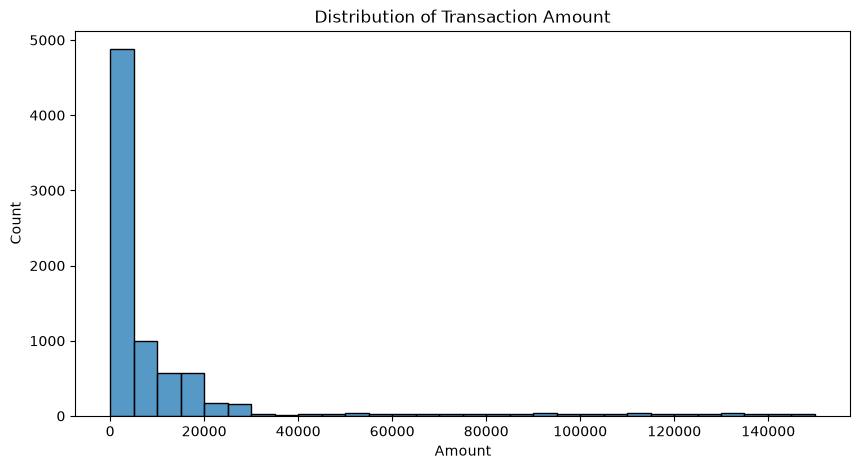

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Amount"],
    bins=30
)

plt.title("Distribution of Transaction Amount")

plt.show()

In [27]:
monthly_spending = (
    df.groupby("Month")["Amount"]
      .sum()
)

In [28]:
monthly_spending

Month
April        7937485.11
August       8692664.18
December     8391272.78
February     7327831.77
January      8093666.23
July         8951073.24
June         9018844.54
March        9390091.29
May          8847821.63
November     8039843.94
October      7022232.93
September    8702808.39
Name: Amount, dtype: float64

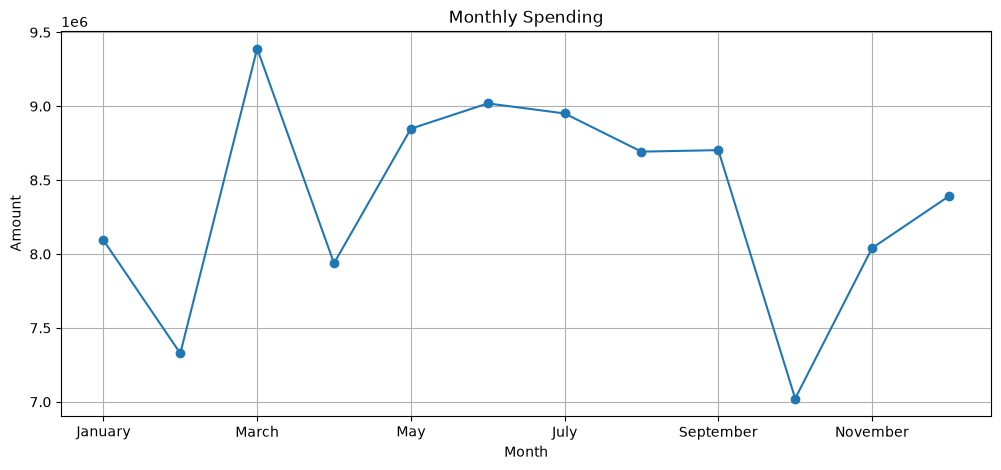

In [29]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_spending = (
    df.groupby("Month")["Amount"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(12,5))

monthly_spending.plot(marker="o")

plt.title("Monthly Spending")

plt.ylabel("Amount")

plt.grid(True)

plt.show()

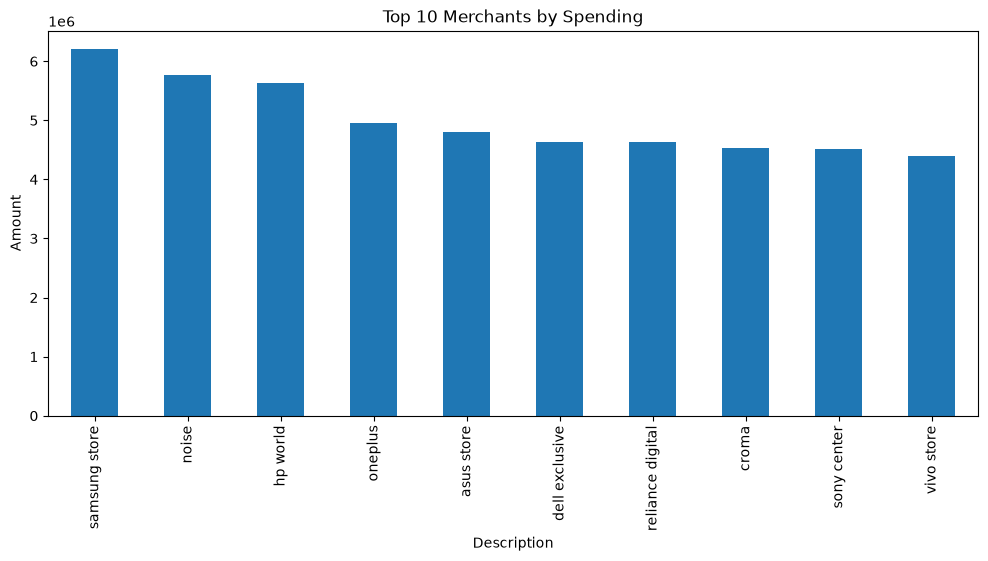

In [30]:
top_merchants = (
    df.groupby("Description")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,5))

top_merchants.plot(kind="bar")

plt.title("Top 10 Merchants by Spending")

plt.ylabel("Amount")

plt.show()

In [31]:
highest = category_spending.idxmax()

print("Highest Spending Category :", highest)

Highest Spending Category : Electronics


In [32]:
df.to_csv("../datasets/cleaned_dataset.csv", index=False)